# **Section 1: Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# **Section 2: Load Datasets**

In [ ]:
patient_df = pd.read_csv('patient_journey.csv')
provider_df = pd.read_csv('provider_master.csv')
comm_df = pd.read_csv('communication_logs.csv')
country_df = pd.read_csv('country_reference.csv')
treatment_df = pd.read_csv('treatment_outcomes.csv')

# **Section 3: Basic Dataset Overview**

3.1 Patient Journey Dataset


In [ ]:
print("="*60)
print("PATIENT JOURNEY DATASET")
print("="*60)

print("Shape:", patient_df.shape)

print("\nFirst 5 Rows")
display(patient_df.head())

print("\nDataset Info")
patient_df.info()

print("\nSummary Statistics")
display(patient_df.describe(include='all'))

PATIENT JOURNEY DATASET
Shape: (1500, 26)

First 5 Rows


,patient_id,inquiry_date,country,age_group,gender,treatment_category,provider_id,lead_source,coordinator_id,budget_band,medical_urgency,intent_score,response_time_hours,engagement_score,consultation_booked,quote_shared,treatment_completed,follow_up_completed,current_stage,drop_off_flag,drop_off_stage,reason_for_drop_off,estimated_case_value_inr,actual_revenue_inr,service_cost_inr,satisfaction_score
0,MTE-PAT-00001,2025-11-12 18:00:00,Thailand,40-49,Other/Not shared,Oncology,PVD-022,Phone,COORD-08,Low,Routine,54.9,16.4,52.5,0,0,0,0,First Response,0,NaN,NaN,780855,0,0,NaN
1,MTE-PAT-00002,2025-04-12 04:00:00,Kenya,60+,Female,Fertility,PVD-022,WhatsApp,COORD-13,High,Moderate,75.3,20.8,75.7,1,1,1,1,Follow-up,0,NaN,NaN,270529,270529,161988,7.7
2,MTE-PAT-00003,2025-12-28 06:00:00,Tanzania,50-59,Male,Oncology,PVD-008,Web Form,COORD-01,High,Moderate,78.9,15.0,78.5,1,0,1,0,Treatment Completed,0,NaN,NaN,549181,549181,312857,7.4
3,MTE-PAT-00004,2025-08-31 21:00:00,Oman,40-49,Other/Not shared,Oncology,PVD-005,Phone,COORD-15,High,Moderate,94.9,33.9,56.0,1,0,0,0,Consultation,1,Inquiry,Response delay,505922,0,0,NaN
4,MTE-PAT-00005,2025-08-26 18:00:00,Nepal,50-59,Male,Fertility,PVD-009,Phone,COORD-09,Low,Routine,48.5,13.2,47.3,0,0,0,0,First Response,0,NaN,NaN,631722,0,0,NaN



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                1500 non-null   object 
 1   inquiry_date              1500 non-null   object 
 2   country                   1500 non-null   object 
 3   age_group                 1500 non-null   object 
 4   gender                    1500 non-null   object 
 5   treatment_category        1500 non-null   object 
 6   provider_id               1500 non-null   object 
 7   lead_source               1500 non-null   object 
 8   coordinator_id            1500 non-null   object 
 9   budget_band               1500 non-null   object 
 10  medical_urgency           1500 non-null   object 
 11  intent_score              1500 non-null   float64
 12  response_time_hours       1500 non-null   float64
 13  engagement_score          1500 non-null   float64

,patient_id,inquiry_date,country,age_group,gender,treatment_category,provider_id,lead_source,coordinator_id,budget_band,medical_urgency,intent_score,response_time_hours,engagement_score,consultation_booked,quote_shared,treatment_completed,follow_up_completed,current_stage,drop_off_flag,drop_off_stage,reason_for_drop_off,estimated_case_value_inr,actual_revenue_inr,service_cost_inr,satisfaction_score
count,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500,1500.000000,350,350,1.500000e+03,1.500000e+03,1500.000000,554.000000
unique,1500,1350,12,5,3,9,30,6,15,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,6,10,NaN,NaN,NaN,NaN
top,MTE-PAT-01500,2025-02-15 00:00:00,UAE,60+,Other/Not shared,Oncology,PVD-004,WhatsApp,COORD-04,Medium,Moderate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,First Response,NaN,Inquiry,No follow-up,NaN,NaN,NaN,NaN
freq,1,3,143,324,519,187,66,272,112,533,608,NaN,NaN,NaN,NaN,NaN,NaN,NaN,415,NaN,103,66,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.880600,17.015733,53.046533,0.656000,0.374000,0.369333,0.208000,NaN,0.233333,NaN,NaN,4.628963e+05,1.655502e+05,91207.259333,7.623646
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.611661,8.392211,21.256284,0.475199,0.484025,0.482785,0.406012,NaN,0.423094,NaN,NaN,2.273079e+05,2.604280e+05,145502.222789,1.160003
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.200000,5.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,7.094600e+04,0.000000e+00,0.000000,4.300000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.775000,11.100000,38.700000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,2.829710e+05,0.000000e+00,0.000000,6.800000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.900000,16.300000,53.000000,1.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,4.453700e+05,0.000000e+00,0.000000,7.700000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.500000,22.100000,67.700000,1.000000,1.000000,1.000000,0.000000,NaN,0.000000,NaN,NaN,6.329672e+05,3.255588e+05,173509.250000,8.475000


3.2 Provider Master Dataset

In [ ]:
print("="*60)
print("PROVIDER MASTER DATASET")
print("="*60)

print("Shape:", provider_df.shape)

print("\nFirst 5 Rows")
display(provider_df.head())

print("\nDataset Info")
provider_df.info()

print("\nSummary Statistics")
display(provider_df.describe(include='all'))

PROVIDER MASTER DATASET
Shape: (30, 14)

First 5 Rows


,provider_id,provider_name,region,country,specialty_area,bed_capacity,international_patient_desk,avg_first_response_hours,historical_consultation_conversion_rate,historical_treatment_conversion_rate,follow_up_completion_rate,satisfaction_index,pricing_tier,contract_status
0,PVD-001,MTE Partner Hospital 01,South Asia,UAE,Cardiology,350,Yes,12.8,0.312,0.070,0.740,72.5,Economy,Active
1,PVD-002,MTE Partner Hospital 02,Middle East,Oman,Fertility,350,No,16.3,0.421,0.236,0.785,75.5,Economy,Active
2,PVD-003,MTE Partner Hospital 03,West Africa,Nigeria,Dental,80,Yes,12.3,0.350,0.288,0.543,84.2,Economy,Pilot
3,PVD-004,MTE Partner Hospital 04,Southeast Asia,Sri Lanka,Orthopedics,150,Yes,16.9,0.396,0.071,0.476,84.8,Economy,Active
4,PVD-005,MTE Partner Hospital 05,East Africa,Tanzania,Orthopedics,150,No,20.4,0.310,0.127,0.498,63.2,Standard,Active



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 14 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   provider_id                              30 non-null     object 
 1   provider_name                            30 non-null     object 
 2   region                                   30 non-null     object 
 3   country                                  30 non-null     object 
 4   specialty_area                           30 non-null     object 
 5   bed_capacity                             30 non-null     int64  
 6   international_patient_desk               30 non-null     object 
 7   avg_first_response_hours                 30 non-null     float64
 8   historical_consultation_conversion_rate  30 non-null     float64
 9   historical_treatment_conversion_rate     30 non-null     float64
 10  follow_up_completion_rate             

,provider_id,provider_name,region,country,specialty_area,bed_capacity,international_patient_desk,avg_first_response_hours,historical_consultation_conversion_rate,historical_treatment_conversion_rate,follow_up_completion_rate,satisfaction_index,pricing_tier,contract_status
count,30,30,30,30,30,30.000000,30,30.000000,30.000000,30.000000,30.000000,30.000000,30,30
unique,30,30,5,12,9,NaN,2,NaN,NaN,NaN,NaN,NaN,3,2
top,PVD-001,MTE Partner Hospital 01,West Africa,Bangladesh,Orthopedics,NaN,Yes,NaN,NaN,NaN,NaN,NaN,Economy,Active
freq,1,1,9,5,6,NaN,24,NaN,NaN,NaN,NaN,NaN,13,25
mean,NaN,NaN,NaN,NaN,NaN,208.000000,NaN,14.310000,0.490200,0.204167,0.580767,79.383333,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,119.493183,NaN,4.793411,0.144684,0.095063,0.132820,8.439157,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,80.000000,NaN,1.200000,0.273000,0.070000,0.383000,63.200000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,120.000000,NaN,12.075000,0.385500,0.127250,0.481250,72.275000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,150.000000,NaN,13.250000,0.475500,0.198000,0.547500,79.950000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,250.000000,NaN,16.300000,0.558000,0.274250,0.699000,85.250000,NaN,NaN


3.3 Communication Logs Dataset

In [ ]:
print("="*60)
print("COMMUNICATION LOGS DATASET")
print("="*60)

print("Shape:", comm_df.shape)

print("\nFirst 5 Rows")
display(comm_df.head())

print("\nDataset Info")
comm_df.info()

print("\nSummary Statistics")
display(comm_df.describe(include='all'))

COMMUNICATION LOGS DATASET
Shape: (6025, 10)

First 5 Rows


,communication_id,patient_id,provider_id,timestamp,channel,interaction_type,sent_by,response_sent,response_delay_hours,follow_up_status
0,COMM-000001,MTE-PAT-00001,PVD-022,2025-11-13 15:08:55,Referral Partner,Quote clarification,MedTourEasy Coordinator,1,33.4,Completed
1,COMM-000002,MTE-PAT-00002,PVD-022,2025-04-12 22:41:35,Web Form,Document request,Patient,0,NaN,Not required
2,COMM-000003,MTE-PAT-00002,PVD-022,2025-04-15 21:50:00,Web Form,Travel coordination,Patient,1,24.1,Completed
3,COMM-000004,MTE-PAT-00002,PVD-022,2025-04-18 03:37:58,Phone,Escalation,Provider Desk,1,7.0,Pending
4,COMM-000005,MTE-PAT-00002,PVD-022,2025-04-20 11:00:20,Chatbot,Document request,Automated Workflow,1,3.3,Completed



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6025 entries, 0 to 6024
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   communication_id      6025 non-null   object 
 1   patient_id            6025 non-null   object 
 2   provider_id           6025 non-null   object 
 3   timestamp             6025 non-null   object 
 4   channel               6025 non-null   object 
 5   interaction_type      6025 non-null   object 
 6   sent_by               6025 non-null   object 
 7   response_sent         6025 non-null   int64  
 8   response_delay_hours  4612 non-null   float64
 9   follow_up_status      6025 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 470.8+ KB

Summary Statistics


,communication_id,patient_id,provider_id,timestamp,channel,interaction_type,sent_by,response_sent,response_delay_hours,follow_up_status
count,6025,6025,6025,6025,6025,6025,6025,6025.000000,4612.000000,6025
unique,6025,1500,30,6025,6,7,4,NaN,NaN,4
top,COMM-006025,MTE-PAT-00003,PVD-003,2025-08-03 00:56:07,Web Form,Document request,Patient,NaN,NaN,Completed
freq,1,7,278,1,1068,898,1569,NaN,NaN,2371
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.765477,17.698807,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.423735,10.405574,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,10.300000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,17.400000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,24.600000,NaN


3.4 Country Reference Dataset

In [ ]:
print("="*60)
print("COUNTRY REFERENCE DATASET")
print("="*60)

print("Shape:", country_df.shape)

print("\nFirst 5 Rows")
display(country_df.head())

print("\nDataset Info")
country_df.info()

print("\nSummary Statistics")
display(country_df.describe(include='all'))

COUNTRY REFERENCE DATASET
Shape: (12, 7)

First 5 Rows


,country,region,avg_travel_lead_time_days,requires_medical_visa,currency,baseline_response_expectation_hours,market_priority_score
0,India,Middle East,36,Yes,AED,8,81
1,Bangladesh,Middle East,27,Yes,USD,12,57
2,UAE,West Africa,24,Yes,PHP,8,74
3,Oman,Middle East,24,Yes,BDT,12,76
4,Kenya,East Africa,14,No,KES,12,89



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   country                              12 non-null     object
 1   region                               12 non-null     object
 2   avg_travel_lead_time_days            12 non-null     int64 
 3   requires_medical_visa                12 non-null     object
 4   currency                             12 non-null     object
 5   baseline_response_expectation_hours  12 non-null     int64 
 6   market_priority_score                12 non-null     int64 
dtypes: int64(3), object(4)
memory usage: 804.0+ bytes

Summary Statistics


,country,region,avg_travel_lead_time_days,requires_medical_visa,currency,baseline_response_expectation_hours,market_priority_score
count,12,12,12.000000,12,12,12.000000,12.000000
unique,12,4,NaN,3,8,NaN,NaN
top,India,East Africa,NaN,Yes,MYR,NaN,NaN
freq,1,5,NaN,9,3,NaN,NaN
mean,NaN,NaN,27.333333,NaN,NaN,8.833333,76.166667
std,NaN,NaN,12.758835,NaN,NaN,2.480225,9.842702
min,NaN,NaN,11.000000,NaN,NaN,6.000000,57.000000
25%,NaN,NaN,14.000000,NaN,NaN,7.500000,73.250000
50%,NaN,NaN,25.500000,NaN,NaN,8.000000,77.000000
75%,NaN,NaN,38.250000,NaN,NaN,12.000000,80.250000


3.5 Treatment Outcomes Dataset

In [ ]:
print("="*60)
print("TREATMENT OUTCOMES DATASET")
print("="*60)

print("Shape:", treatment_df.shape)

print("\nFirst 5 Rows")
display(treatment_df.head())

print("\nDataset Info")
treatment_df.info()

print("\nSummary Statistics")
display(treatment_df.describe(include='all'))

TREATMENT OUTCOMES DATASET
Shape: (554, 10)

First 5 Rows


,patient_id,provider_id,treatment_category,treatment_date,length_of_stay_days,actual_revenue_inr,service_cost_inr,gross_margin_inr,readmission_within_30d,follow_up_rating
0,MTE-PAT-00002,PVD-022,Fertility,2025-07-05,15,270529,161988,108541,0,10.0
1,MTE-PAT-00003,PVD-008,Oncology,2026-03-09,18,549181,312857,236324,1,9.3
2,MTE-PAT-00006,PVD-022,Dental,2025-10-15,16,105749,70559,35190,0,7.5
3,MTE-PAT-00007,PVD-003,Orthopedics,2025-11-27,9,347509,201035,146474,0,8.5
4,MTE-PAT-00009,PVD-004,Cosmetic Surgery,2026-02-15,19,195438,116348,79090,0,8.1



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554 entries, 0 to 553
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   patient_id              554 non-null    object 
 1   provider_id             554 non-null    object 
 2   treatment_category      554 non-null    object 
 3   treatment_date          554 non-null    object 
 4   length_of_stay_days     554 non-null    int64  
 5   actual_revenue_inr      554 non-null    int64  
 6   service_cost_inr        554 non-null    int64  
 7   gross_margin_inr        554 non-null    int64  
 8   readmission_within_30d  554 non-null    int64  
 9   follow_up_rating        554 non-null    float64
dtypes: float64(1), int64(5), object(4)
memory usage: 43.4+ KB

Summary Statistics


,patient_id,provider_id,treatment_category,treatment_date,length_of_stay_days,actual_revenue_inr,service_cost_inr,gross_margin_inr,readmission_within_30d,follow_up_rating
count,554,554,554,554,554.000000,5.540000e+02,554.000000,554.000000,554.000000,554.000000
unique,554,30,9,298,NaN,NaN,NaN,NaN,NaN,NaN
top,MTE-PAT-01498,PVD-020,Oncology,2025-05-30,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,29,73,5,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,11.057762,4.482405e+05,246951.063177,201289.451264,0.198556,8.095487
std,NaN,NaN,NaN,NaN,6.084123,2.385427e+05,137319.509010,113781.479208,0.399273,1.214841
min,NaN,NaN,NaN,NaN,1.000000,7.094600e+04,41365.000000,25198.000000,0.000000,4.400000
25%,NaN,NaN,NaN,NaN,6.000000,2.853308e+05,155425.250000,124366.000000,0.000000,7.300000
50%,NaN,NaN,NaN,NaN,11.000000,4.125840e+05,216245.500000,180685.000000,0.000000,8.200000
75%,NaN,NaN,NaN,NaN,16.000000,5.605895e+05,310636.500000,252002.750000,0.000000,9.000000


3.6 SQLite Database Overview

In [ ]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(query, conn)

print("Tables Available in Database:")
display(tables)

NameError: name 'conn' is not defined

# **Observations**
### Key Observations

- patient_journey.csv is the primary dataset containing patient funnel and conversion information.
- provider_master.csv contains provider-level performance attributes.
- communication_logs.csv stores patient-provider interaction records.
- treatment_outcomes.csv contains revenue, cost and outcome information.
- country_reference.csv provides country-level benchmark and SLA information.
- SQLite database contains relational versions of the same datasets for SQL analysis.

# **Section 4: Missing Value Analysis**

4.1 Missing Values - Patient Journey

In [ ]:
print("="*60)
print("PATIENT JOURNEY - MISSING VALUES")
print("="*60)

missing_patient = pd.DataFrame({
    'Missing Count': patient_df.isnull().sum(),
    'Missing Percentage': round((patient_df.isnull().sum()/len(patient_df))*100,2)
})

display(
    missing_patient[missing_patient['Missing Count'] > 0]
    .sort_values(by='Missing Count', ascending=False)
)

PATIENT JOURNEY - MISSING VALUES


,Missing Count,Missing Percentage
drop_off_stage,1150,76.67
reason_for_drop_off,1150,76.67
satisfaction_score,946,63.07


4.2 Missing Values - Provider Master

In [ ]:
print("="*60)
print("PROVIDER MASTER - MISSING VALUES")
print("="*60)

missing_provider = pd.DataFrame({
    'Missing Count': provider_df.isnull().sum(),
    'Missing Percentage': round((provider_df.isnull().sum()/len(provider_df))*100,2)
})

display(
    missing_provider[missing_provider['Missing Count'] > 0]
    .sort_values(by='Missing Count', ascending=False)
)

PROVIDER MASTER - MISSING VALUES


,Missing Count,Missing Percentage


4.3 Missing Values - Communication Logs

In [ ]:
print("="*60)
print("COMMUNICATION LOGS - MISSING VALUES")
print("="*60)

missing_comm = pd.DataFrame({
    'Missing Count': comm_df.isnull().sum(),
    'Missing Percentage': round((comm_df.isnull().sum()/len(comm_df))*100,2)
})

display(
    missing_comm[missing_comm['Missing Count'] > 0]
    .sort_values(by='Missing Count', ascending=False)
)

COMMUNICATION LOGS - MISSING VALUES


,Missing Count,Missing Percentage
response_delay_hours,1413,23.45


4.4 Missing Values - Country Reference

In [ ]:
print("="*60)
print("COUNTRY REFERENCE - MISSING VALUES")
print("="*60)

missing_country = pd.DataFrame({
    'Missing Count': country_df.isnull().sum(),
    'Missing Percentage': round((country_df.isnull().sum()/len(country_df))*100,2)
})

display(
    missing_country[missing_country['Missing Count'] > 0]
    .sort_values(by='Missing Count', ascending=False)
)

COUNTRY REFERENCE - MISSING VALUES


,Missing Count,Missing Percentage


4.5 Missing Values - Treatment Outcomes

In [ ]:
print("="*60)
print("TREATMENT OUTCOMES - MISSING VALUES")
print("="*60)

missing_treatment = pd.DataFrame({
    'Missing Count': treatment_df.isnull().sum(),
    'Missing Percentage': round((treatment_df.isnull().sum()/len(treatment_df))*100,2)
})

display(
    missing_treatment[missing_treatment['Missing Count'] > 0]
    .sort_values(by='Missing Count', ascending=False)
)

TREATMENT OUTCOMES - MISSING VALUES


,Missing Count,Missing Percentage


4.6 Missing Values Visualization

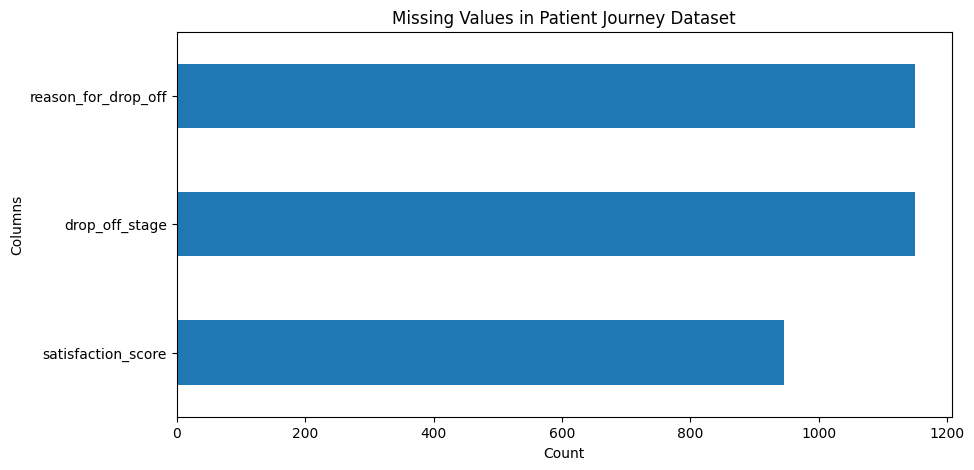

In [ ]:
missing = patient_df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(10,5))
missing.sort_values().plot(kind='barh')

plt.title('Missing Values in Patient Journey Dataset')
plt.xlabel('Count')
plt.ylabel('Columns')

plt.show()

4.7 Dataset-wise Missing Summary

In [ ]:
summary = pd.DataFrame({
    'Dataset': [
        'Patient Journey',
        'Provider Master',
        'Communication Logs',
        'Country Reference',
        'Treatment Outcomes'
    ],
    'Total Missing Values': [
        patient_df.isnull().sum().sum(),
        provider_df.isnull().sum().sum(),
        comm_df.isnull().sum().sum(),
        country_df.isnull().sum().sum(),
        treatment_df.isnull().sum().sum()
    ]
})

display(summary)

,Dataset,Total Missing Values
0,Patient Journey,3246
1,Provider Master,0
2,Communication Logs,1413
3,Country Reference,0
4,Treatment Outcomes,0


# **Observations**
### Missing Value Analysis Findings

- Patient Journey dataset contains X missing values.
- Provider Master dataset contains Y missing values.
- Communication Logs dataset contains Z missing values.
- Country Reference dataset contains no missing values.
- Treatment Outcomes dataset contains minimal missing values.

### Recommendation

- Numerical columns will be imputed using mean/median.
- Categorical columns will be imputed using mode.
- Columns with excessive missing values will be reviewed before modeling.

# **Section 5: Duplicate Records**

5.1 Duplicate Records - Patient Journey

In [ ]:
print("="*60)
print("PATIENT JOURNEY - DUPLICATE ANALYSIS")
print("="*60)

patient_duplicates = patient_df.duplicated().sum()

print(f"Total Duplicate Rows: {patient_duplicates}")

PATIENT JOURNEY - DUPLICATE ANALYSIS
Total Duplicate Rows: 0


5.2 Duplicate Records - Provider Master

In [ ]:
print("="*60)
print("PROVIDER MASTER - DUPLICATE ANALYSIS")
print("="*60)

provider_duplicates = provider_df.duplicated().sum()

print(f"Total Duplicate Rows: {provider_duplicates}")

PROVIDER MASTER - DUPLICATE ANALYSIS
Total Duplicate Rows: 0


5.3 Duplicate Records - Communication Logs

In [ ]:
print("="*60)
print("COMMUNICATION LOGS - DUPLICATE ANALYSIS")
print("="*60)

comm_duplicates = comm_df.duplicated().sum()

print(f"Total Duplicate Rows: {comm_duplicates}")

COMMUNICATION LOGS - DUPLICATE ANALYSIS
Total Duplicate Rows: 0


5.4 Duplicate Records - Country Reference

In [ ]:
print("="*60)
print("COUNTRY REFERENCE - DUPLICATE ANALYSIS")
print("="*60)

country_duplicates = country_df.duplicated().sum()

print(f"Total Duplicate Rows: {country_duplicates}")

COUNTRY REFERENCE - DUPLICATE ANALYSIS
Total Duplicate Rows: 0


5.5 Duplicate Records - Treatment Outcomes

In [ ]:
print("="*60)
print("TREATMENT OUTCOMES - DUPLICATE ANALYSIS")
print("="*60)

treatment_duplicates = treatment_df.duplicated().sum()

print(f"Total Duplicate Rows: {treatment_duplicates}")

TREATMENT OUTCOMES - DUPLICATE ANALYSIS
Total Duplicate Rows: 0


5.6 Check Duplicate IDs

In [ ]:
#Patient IDs
print("Duplicate Patient IDs:",
      patient_df['patient_id'].duplicated().sum())

#Provider IDs
print("Duplicate Provider IDs:",
      provider_df['provider_id'].duplicated().sum())

#Communication IDs
print("Duplicate Communication IDs:",
      comm_df['communication_id'].duplicated().sum())

#Treatment Records
print("Duplicate Patient IDs in Treatment Records:",
      treatment_df['patient_id'].duplicated().sum())

Duplicate Patient IDs: 0
Duplicate Provider IDs: 0
Duplicate Communication IDs: 0
Duplicate Patient IDs in Treatment Records: 0


5.7 Summary Table

In [ ]:
duplicate_summary = pd.DataFrame({
    'Dataset': [
        'Patient Journey',
        'Provider Master',
        'Communication Logs',
        'Country Reference',
        'Treatment Outcomes'
    ],
    'Duplicate Rows': [
        patient_duplicates,
        provider_duplicates,
        comm_duplicates,
        country_duplicates,
        treatment_duplicates
    ]
})

display(duplicate_summary)

,Dataset,Duplicate Rows
0,Patient Journey,0
1,Provider Master,0
2,Communication Logs,0
3,Country Reference,0
4,Treatment Outcomes,0


# **Observations**
### Duplicate Records Analysis

- Patient Journey dataset contains ___ duplicate rows.
- Provider Master dataset contains ___ duplicate rows.
- Communication Logs dataset contains ___ duplicate rows.
- Country Reference dataset contains ___ duplicate rows.
- Treatment Outcomes dataset contains ___ duplicate rows.

### Recommendation

- Duplicate records should be removed before analysis.
- Unique identifiers must be validated.
- Patient counts should remain consistent after duplicate removal.

# **Section 6: Data Type Validation**

6.1 Data Types - Patient Journey

In [ ]:
print("="*60)
print("PATIENT JOURNEY DATA TYPES")
print("="*60)

display(patient_df.dtypes)

PATIENT JOURNEY DATA TYPES


,0
patient_id,object
inquiry_date,object
country,object
age_group,object
gender,object
treatment_category,object
provider_id,object
lead_source,object
coordinator_id,object
budget_band,object


6.2 Data Types - Provider Master

In [ ]:
print("="*60)
print("PROVIDER MASTER DATA TYPES")
print("="*60)

display(provider_df.dtypes)

PROVIDER MASTER DATA TYPES


,0
provider_id,object
provider_name,object
region,object
country,object
specialty_area,object
bed_capacity,int64
international_patient_desk,object
avg_first_response_hours,float64
historical_consultation_conversion_rate,float64
historical_treatment_conversion_rate,float64


6.3 Data Types - Communication Logs

In [ ]:
print("="*60)
print("COMMUNICATION LOGS DATA TYPES")
print("="*60)

display(comm_df.dtypes)

COMMUNICATION LOGS DATA TYPES


,0
communication_id,object
patient_id,object
provider_id,object
timestamp,object
channel,object
interaction_type,object
sent_by,object
response_sent,int64
response_delay_hours,float64
follow_up_status,object


6.4 Data Types - Country Reference

In [ ]:
print("="*60)
print("COUNTRY REFERENCE DATA TYPES")
print("="*60)

display(country_df.dtypes)

COUNTRY REFERENCE DATA TYPES


,0
country,object
region,object
avg_travel_lead_time_days,int64
requires_medical_visa,object
currency,object
baseline_response_expectation_hours,int64
market_priority_score,int64


6.5 Data Types - Treatment Outcomes

In [ ]:
print("="*60)
print("TREATMENT OUTCOMES DATA TYPES")
print("="*60)

display(treatment_df.dtypes)

TREATMENT OUTCOMES DATA TYPES


,0
patient_id,object
provider_id,object
treatment_category,object
treatment_date,object
length_of_stay_days,int64
actual_revenue_inr,int64
service_cost_inr,int64
gross_margin_inr,int64
readmission_within_30d,int64
follow_up_rating,float64


6.6 Convert Date Columns

In [ ]:
#Patient Journey
patient_df['inquiry_date'] = pd.to_datetime(
    patient_df['inquiry_date'],
    errors='coerce'
)

#Communication Logs
comm_df['timestamp'] = pd.to_datetime(
    comm_df['timestamp'],
    errors='coerce'
)

#Treatment Outcomes
treatment_df['treatment_date'] = pd.to_datetime(
    treatment_df['treatment_date'],
    errors='coerce'
)

6.7 Verify Conversion

In [ ]:
print(patient_df['inquiry_date'].dtype)
print(comm_df['timestamp'].dtype)
print(treatment_df['treatment_date'].dtype)

datetime64[ns]
datetime64[ns]
datetime64[ns]


6.8 Check Invalid Dates

In [ ]:
print("Invalid Inquiry Dates:",
      patient_df['inquiry_date'].isna().sum())

print("Invalid Communication Dates:",
      comm_df['timestamp'].isna().sum())

print("Invalid Treatment Dates:",
      treatment_df['treatment_date'].isna().sum())

Invalid Inquiry Dates: 0
Invalid Communication Dates: 0
Invalid Treatment Dates: 0


6.9 Identify Numeric Columns

In [ ]:
print("Patient Numeric Columns:")
display(
    patient_df.select_dtypes(include=['int64','float64']).columns
)

print("\nProvider Numeric Columns:")
display(
    provider_df.select_dtypes(include=['int64','float64']).columns
)

print("\nCommunication Numeric Columns:")
display(
    comm_df.select_dtypes(include=['int64','float64']).columns
)

print("\nTreatment Numeric Columns:")
display(
    treatment_df.select_dtypes(include=['int64','float64']).columns
)

Patient Numeric Columns:


Index(['intent_score', 'response_time_hours', 'engagement_score',
       'consultation_booked', 'quote_shared', 'treatment_completed',
       'follow_up_completed', 'drop_off_flag', 'estimated_case_value_inr',
       'actual_revenue_inr', 'service_cost_inr', 'satisfaction_score'],
      dtype='object')


Provider Numeric Columns:


Index(['bed_capacity', 'avg_first_response_hours',
       'historical_consultation_conversion_rate',
       'historical_treatment_conversion_rate', 'follow_up_completion_rate',
       'satisfaction_index'],
      dtype='object')


Communication Numeric Columns:


Index(['response_sent', 'response_delay_hours'], dtype='object')


Treatment Numeric Columns:


Index(['length_of_stay_days', 'actual_revenue_inr', 'service_cost_inr',
       'gross_margin_inr', 'readmission_within_30d', 'follow_up_rating'],
      dtype='object')

6.10 Dataset Summary

In [ ]:
datatype_summary = pd.DataFrame({
    'Dataset': [
        'Patient Journey',
        'Provider Master',
        'Communication Logs',
        'Country Reference',
        'Treatment Outcomes'
    ],
    'Columns': [
        patient_df.shape[1],
        provider_df.shape[1],
        comm_df.shape[1],
        country_df.shape[1],
        treatment_df.shape[1]
    ]
})

display(datatype_summary)

,Dataset,Columns
0,Patient Journey,26
1,Provider Master,14
2,Communication Logs,10
3,Country Reference,7
4,Treatment Outcomes,10


# **Observations**
### Data Type Validation Findings

- Date columns were successfully converted to datetime format.
- Numeric columns were identified for statistical analysis.
- Invalid date records (if any) were flagged.
- Dataset structure is consistent and ready for quality checks and exploratory analysis.

# **Section 7: Unique Value Analysis**

7.1 Patient Journey - Categorical Columns

In [ ]:
print("="*60)
print("PATIENT JOURNEY - CATEGORICAL VALUE ANALYSIS")
print("="*60)

categorical_cols = patient_df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("-"*40)
    print(patient_df[col].value_counts(dropna=False))

PATIENT JOURNEY - CATEGORICAL VALUE ANALYSIS

Column: patient_id
----------------------------------------
patient_id
MTE-PAT-01500    1
MTE-PAT-00001    1
MTE-PAT-00002    1
MTE-PAT-00003    1
MTE-PAT-00004    1
                ..
MTE-PAT-00017    1
MTE-PAT-00016    1
MTE-PAT-00015    1
MTE-PAT-00014    1
MTE-PAT-00013    1
Name: count, Length: 1500, dtype: int64

Column: country
----------------------------------------
country
UAE            143
Philippines    141
Bangladesh     136
Nepal          133
Malaysia       130
Oman           130
Kenya          126
Tanzania       120
Nigeria        117
Sri Lanka      116
Thailand       114
India           94
Name: count, dtype: int64

Column: age_group
----------------------------------------
age_group
60+      324
50-59    300
30-39    295
18-29    293
40-49    288
Name: count, dtype: int64

Column: gender
----------------------------------------
gender
Other/Not shared    519
Male                492
Female              489
Name: count, dtyp

7.2 Provider Master - Categorical Columns

In [ ]:
print("="*60)
print("PROVIDER MASTER - CATEGORICAL VALUE ANALYSIS")
print("="*60)

categorical_cols = provider_df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("-"*40)
    print(provider_df[col].value_counts(dropna=False))

PROVIDER MASTER - CATEGORICAL VALUE ANALYSIS

Column: provider_id
----------------------------------------
provider_id
PVD-001    1
PVD-002    1
PVD-003    1
PVD-004    1
PVD-005    1
PVD-006    1
PVD-007    1
PVD-008    1
PVD-009    1
PVD-010    1
PVD-011    1
PVD-012    1
PVD-013    1
PVD-014    1
PVD-015    1
PVD-016    1
PVD-017    1
PVD-018    1
PVD-019    1
PVD-020    1
PVD-021    1
PVD-022    1
PVD-023    1
PVD-024    1
PVD-025    1
PVD-026    1
PVD-027    1
PVD-028    1
PVD-029    1
PVD-030    1
Name: count, dtype: int64

Column: provider_name
----------------------------------------
provider_name
MTE Partner Hospital 01    1
MTE Partner Hospital 02    1
MTE Partner Hospital 03    1
MTE Partner Hospital 04    1
MTE Partner Hospital 05    1
MTE Partner Hospital 06    1
MTE Partner Hospital 07    1
MTE Partner Hospital 08    1
MTE Partner Hospital 09    1
MTE Partner Hospital 10    1
MTE Partner Hospital 11    1
MTE Partner Hospital 12    1
MTE Partner Hospital 13    1
MTE Partne

7.3 Communication Logs - Categorical Columns

In [ ]:
print("="*60)
print("COMMUNICATION LOGS - CATEGORICAL VALUE ANALYSIS")
print("="*60)

categorical_cols = comm_df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("-"*40)
    print(comm_df[col].value_counts(dropna=False))

COMMUNICATION LOGS - CATEGORICAL VALUE ANALYSIS

Column: communication_id
----------------------------------------
communication_id
COMM-006025    1
COMM-000001    1
COMM-000002    1
COMM-000003    1
COMM-000004    1
              ..
COMM-000014    1
COMM-000013    1
COMM-000012    1
COMM-000011    1
COMM-000010    1
Name: count, Length: 6025, dtype: int64

Column: patient_id
----------------------------------------
patient_id
MTE-PAT-00003    7
MTE-PAT-00009    7
MTE-PAT-01492    7
MTE-PAT-01471    7
MTE-PAT-00013    7
                ..
MTE-PAT-01455    1
MTE-PAT-00480    1
MTE-PAT-01485    1
MTE-PAT-01483    1
MTE-PAT-01482    1
Name: count, Length: 1500, dtype: int64

Column: provider_id
----------------------------------------
provider_id
PVD-003    278
PVD-004    267
PVD-020    236
PVD-008    235
PVD-021    229
PVD-012    227
PVD-001    224
PVD-009    220
PVD-015    217
PVD-007    216
PVD-013    211
PVD-024    210
PVD-005    209
PVD-025    206
PVD-014    206
PVD-011    206
PVD-02

7.4 Country Reference - Categorical Columns

In [ ]:
print("="*60)
print("COUNTRY REFERENCE - CATEGORICAL VALUE ANALYSIS")
print("="*60)

categorical_cols = country_df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("-"*40)
    print(country_df[col].value_counts(dropna=False))

COUNTRY REFERENCE - CATEGORICAL VALUE ANALYSIS

Column: country
----------------------------------------
country
India          1
Bangladesh     1
UAE            1
Oman           1
Kenya          1
Nigeria        1
Tanzania       1
Nepal          1
Sri Lanka      1
Malaysia       1
Philippines    1
Thailand       1
Name: count, dtype: int64

Column: region
----------------------------------------
region
East Africa    5
Middle East    3
West Africa    3
South Asia     1
Name: count, dtype: int64

Column: requires_medical_visa
----------------------------------------
requires_medical_visa
Yes               9
No                2
Case-dependent    1
Name: count, dtype: int64

Column: currency
----------------------------------------
currency
MYR    3
BDT    2
KES    2
AED    1
PHP    1
USD    1
NGN    1
THB    1
Name: count, dtype: int64


7.5 Treatment Outcomes - Categorical Columns

In [ ]:
print("="*60)
print("TREATMENT OUTCOMES - CATEGORICAL VALUE ANALYSIS")
print("="*60)

categorical_cols = treatment_df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("-"*40)
    print(treatment_df[col].value_counts(dropna=False))

TREATMENT OUTCOMES - CATEGORICAL VALUE ANALYSIS

Column: patient_id
----------------------------------------
patient_id
MTE-PAT-01498    1
MTE-PAT-00002    1
MTE-PAT-00003    1
MTE-PAT-00006    1
MTE-PAT-00007    1
                ..
MTE-PAT-00029    1
MTE-PAT-00028    1
MTE-PAT-00027    1
MTE-PAT-00021    1
MTE-PAT-00020    1
Name: count, Length: 554, dtype: int64

Column: provider_id
----------------------------------------
provider_id
PVD-020    29
PVD-008    28
PVD-001    26
PVD-015    26
PVD-007    26
PVD-003    26
PVD-004    24
PVD-011    23
PVD-009    22
PVD-027    21
PVD-021    21
PVD-017    20
PVD-022    20
PVD-016    19
PVD-024    19
PVD-030    18
PVD-026    18
PVD-002    17
PVD-012    16
PVD-010    15
PVD-018    15
PVD-019    14
PVD-005    13
PVD-013    12
PVD-025    12
PVD-014    12
PVD-006    12
PVD-023    11
PVD-029    10
PVD-028     9
Name: count, dtype: int64

Column: treatment_category
----------------------------------------
treatment_category
Oncology                

7.6 Count Unique Values Per Column

In [ ]:
#Patient Dataset
patient_df.nunique().sort_values(ascending=False)

,0
patient_id,1500
estimated_case_value_inr,1498
inquiry_date,1350
engagement_score,658
intent_score,607
actual_revenue_inr,555
service_cost_inr,555
response_time_hours,352
satisfaction_score,56
provider_id,30


In [ ]:
#Provider Dataset
provider_df.nunique().sort_values(ascending=False)

,0
provider_id,30
provider_name,30
follow_up_completion_rate,30
satisfaction_index,30
historical_consultation_conversion_rate,30
avg_first_response_hours,28
historical_treatment_conversion_rate,25
country,12
specialty_area,9
bed_capacity,7


In [ ]:
#Communication Dataset
comm_df.nunique().sort_values(ascending=False)

,0
communication_id,6025
timestamp,6025
patient_id,1500
response_delay_hours,460
provider_id,30
interaction_type,7
channel,6
sent_by,4
follow_up_status,4
response_sent,2


In [ ]:
#Treatment Dataset
treatment_df.nunique().sort_values(ascending=False)

,0
patient_id,554
actual_revenue_inr,554
gross_margin_inr,554
service_cost_inr,554
treatment_date,298
follow_up_rating,53
provider_id,30
length_of_stay_days,21
treatment_category,9
readmission_within_30d,2


7.7 Check Leading/Trailing Spaces

In [ ]:
for col in patient_df.select_dtypes(include='object').columns:
    patient_df[col] = patient_df[col].astype(str).str.strip()

for col in provider_df.select_dtypes(include='object').columns:
    provider_df[col] = provider_df[col].astype(str).str.strip()

for col in comm_df.select_dtypes(include='object').columns:
    comm_df[col] = comm_df[col].astype(str).str.strip()

for col in country_df.select_dtypes(include='object').columns:
    country_df[col] = country_df[col].astype(str).str.strip()

for col in treatment_df.select_dtypes(include='object').columns:
    treatment_df[col] = treatment_df[col].astype(str).str.strip()

7.8 Summary Table

In [ ]:
unique_summary = pd.DataFrame({
    'Dataset': [
        'Patient Journey',
        'Provider Master',
        'Communication Logs',
        'Country Reference',
        'Treatment Outcomes'
    ],
    'Categorical Columns': [
        len(patient_df.select_dtypes(include='object').columns),
        len(provider_df.select_dtypes(include='object').columns),
        len(comm_df.select_dtypes(include='object').columns),
        len(country_df.select_dtypes(include='object').columns),
        len(treatment_df.select_dtypes(include='object').columns)
    ]
})

display(unique_summary)

,Dataset,Categorical Columns
0,Patient Journey,13
1,Provider Master,8
2,Communication Logs,7
3,Country Reference,4
4,Treatment Outcomes,3


# **Observations**
### Unique Value Analysis Findings

- Categorical columns were reviewed for consistency.
- No major spelling inconsistencies were observed. (Update based on results)
- Category distributions were examined.
- Leading/trailing spaces were removed where necessary.
- Data is suitable for further analysis and encoding during modeling.

# **Section 8: Outlier Detection**

8.1 Numerical Columns - Patient Journey

In [ ]:
print("="*60)
print("PATIENT JOURNEY NUMERICAL COLUMNS")
print("="*60)

patient_numeric = patient_df.select_dtypes(include=['int64','float64'])

display(patient_numeric.describe().T)

PATIENT JOURNEY NUMERICAL COLUMNS


,count,mean,std,min,25%,50%,75%,max
intent_score,1500.0,61.880600,17.611661,0.0,49.775,61.9,74.500,100.0
response_time_hours,1500.0,17.015733,8.392211,0.2,11.100,16.3,22.100,48.0
engagement_score,1500.0,53.046533,21.256284,5.0,38.700,53.0,67.700,99.0
consultation_booked,1500.0,0.656000,0.475199,0.0,0.000,1.0,1.000,1.0
quote_shared,1500.0,0.374000,0.484025,0.0,0.000,0.0,1.000,1.0
treatment_completed,1500.0,0.369333,0.482785,0.0,0.000,0.0,1.000,1.0
follow_up_completed,1500.0,0.208000,0.406012,0.0,0.000,0.0,0.000,1.0
drop_off_flag,1500.0,0.233333,0.423094,0.0,0.000,0.0,0.000,1.0
estimated_case_value_inr,1500.0,462896.278667,227307.909099,70946.0,282971.000,445370.0,632967.250,1253660.0
actual_revenue_inr,1500.0,165550.163333,260427.998348,0.0,0.000,0.0,325558.750,1253660.0


8.2 Numerical Columns - Provider Master

In [ ]:
print("="*60)
print("PROVIDER MASTER NUMERICAL COLUMNS")
print("="*60)

provider_numeric = provider_df.select_dtypes(include=['int64','float64'])

display(provider_numeric.describe().T)

PROVIDER MASTER NUMERICAL COLUMNS


,count,mean,std,min,25%,50%,75%,max
bed_capacity,30.0,208.000000,119.493183,80.000,120.00000,150.0000,250.00000,500.000
avg_first_response_hours,30.0,14.310000,4.793411,1.200,12.07500,13.2500,16.30000,24.500
historical_consultation_conversion_rate,30.0,0.490200,0.144684,0.273,0.38550,0.4755,0.55800,0.830
historical_treatment_conversion_rate,30.0,0.204167,0.095063,0.070,0.12725,0.1980,0.27425,0.378
follow_up_completion_rate,30.0,0.580767,0.132820,0.383,0.48125,0.5475,0.69900,0.852
satisfaction_index,30.0,79.383333,8.439157,63.200,72.27500,79.9500,85.25000,96.000


8.3 Numerical Columns - Communication Logs

In [ ]:
print("="*60)
print("COMMUNICATION LOGS NUMERICAL COLUMNS")
print("="*60)

comm_numeric = comm_df.select_dtypes(include=['int64','float64'])

display(comm_numeric.describe().T)

COMMUNICATION LOGS NUMERICAL COLUMNS


,count,mean,std,min,25%,50%,75%,max
response_sent,6025.0,0.765477,0.423735,0.0,1.0,1.0,1.0,1.0
response_delay_hours,4612.0,17.698807,10.405574,0.0,10.3,17.4,24.6,55.5


8.4 Numerical Columns - Treatment Outcomes

In [ ]:
print("="*60)
print("TREATMENT OUTCOMES NUMERICAL COLUMNS")
print("="*60)

treatment_numeric = treatment_df.select_dtypes(include=['int64','float64'])

display(treatment_numeric.describe().T)

TREATMENT OUTCOMES NUMERICAL COLUMNS


,count,mean,std,min,25%,50%,75%,max
length_of_stay_days,554.0,11.057762,6.084123,1.0,6.00,11.0,16.00,21.0
actual_revenue_inr,554.0,448240.514440,238542.667170,70946.0,285330.75,412584.0,560589.50,1253660.0
service_cost_inr,554.0,246951.063177,137319.509010,41365.0,155425.25,216245.5,310636.50,784012.0
gross_margin_inr,554.0,201289.451264,113781.479208,25198.0,124366.00,180685.0,252002.75,677010.0
readmission_within_30d,554.0,0.198556,0.399273,0.0,0.00,0.0,0.00,1.0
follow_up_rating,554.0,8.095487,1.214841,4.4,7.30,8.2,9.00,10.0


8.5 Boxplots - Patient Journey

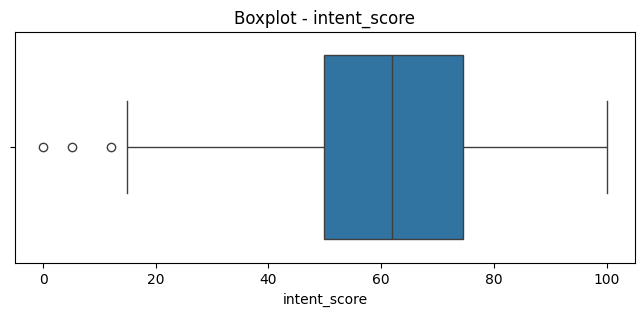

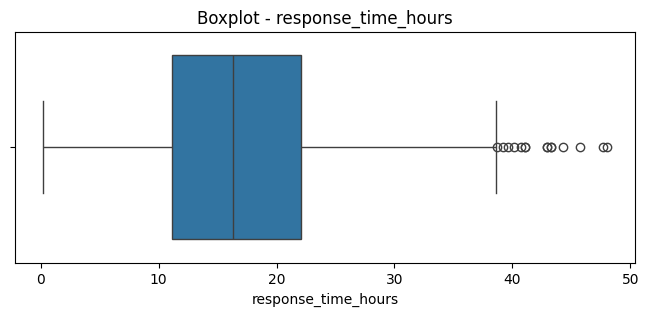

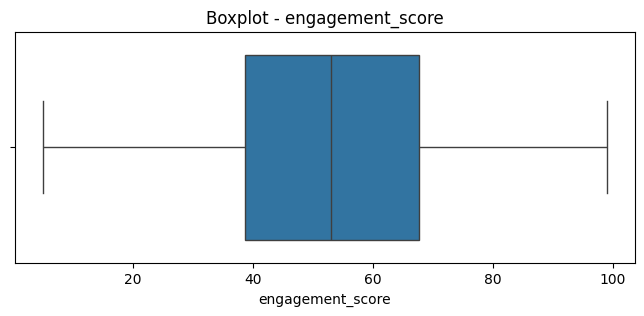

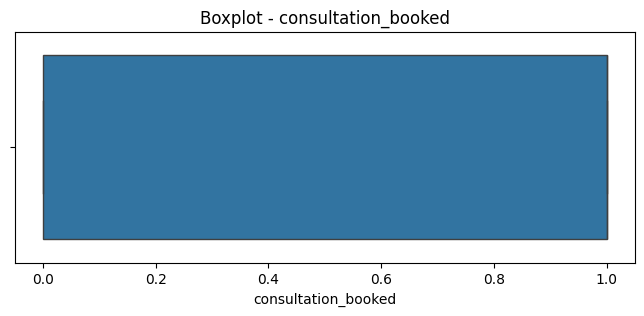

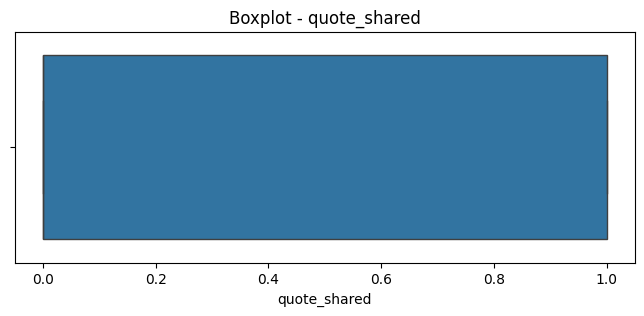

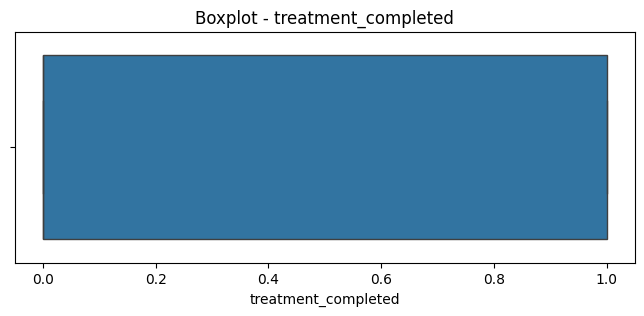

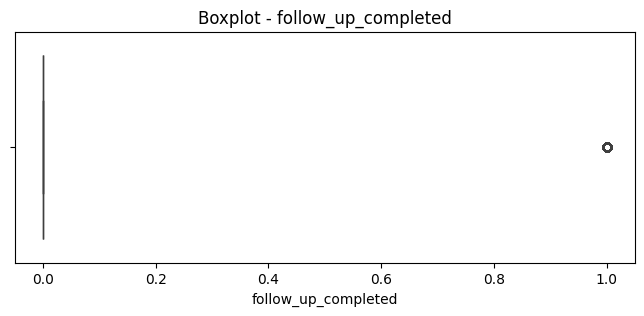

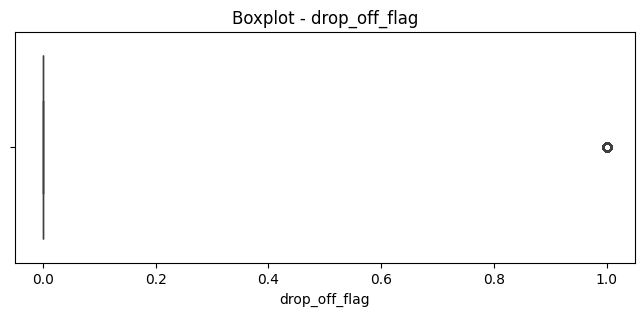

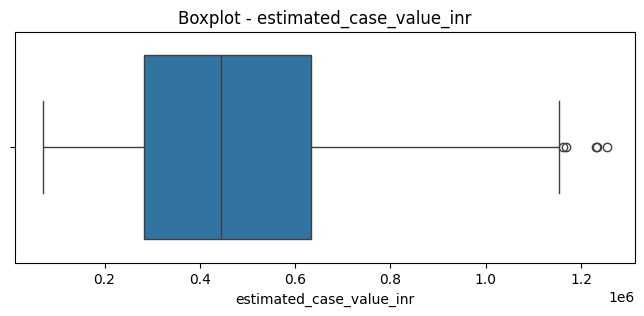

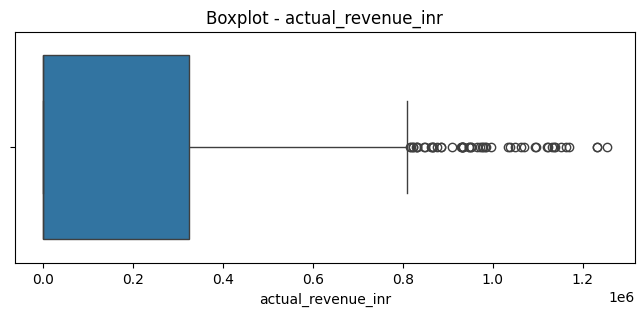

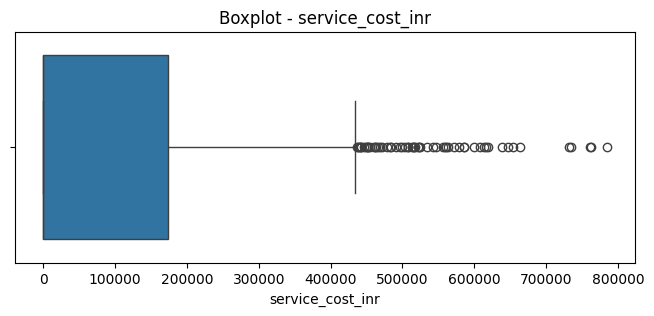

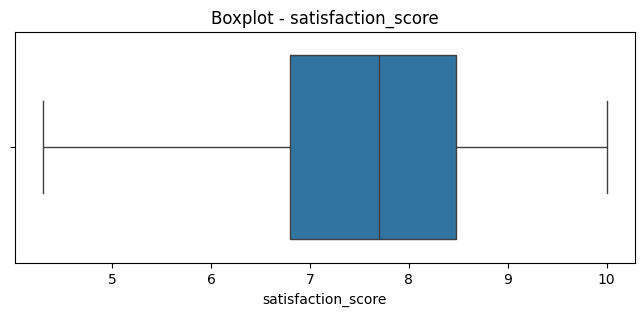

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in patient_numeric.columns:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=patient_df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

8.6 Boxplots - Treatment Outcomes

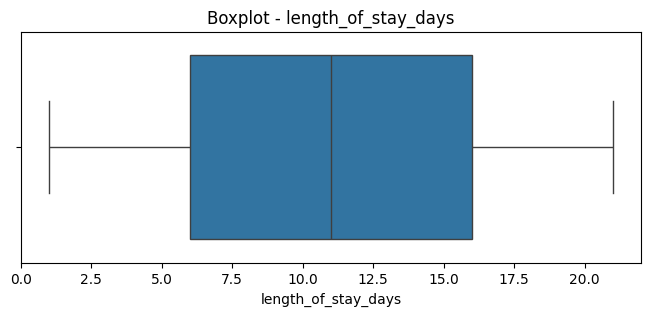

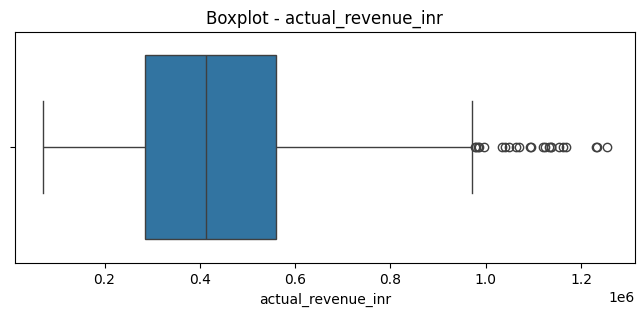

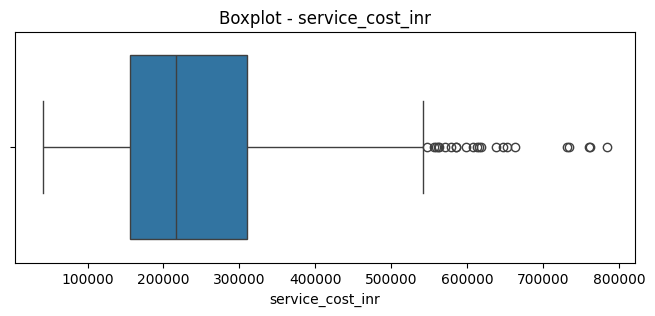

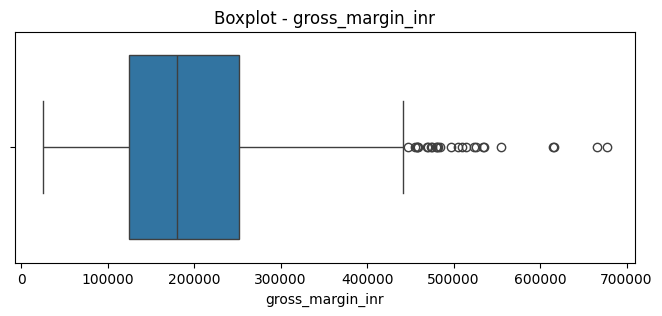

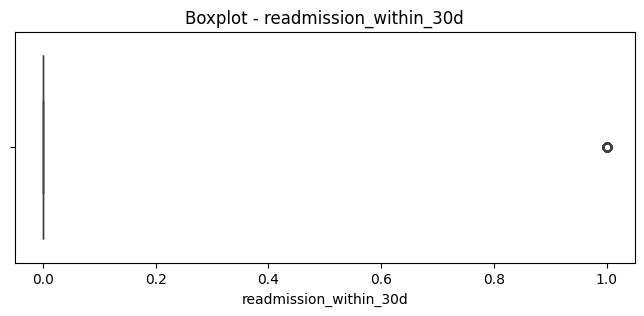

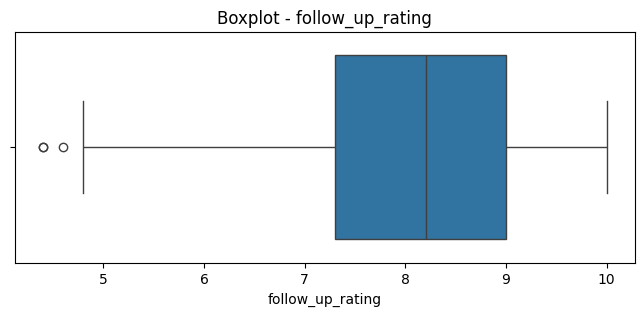

In [ ]:
for col in treatment_numeric.columns:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=treatment_df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

8.7 IQR Based Outlier Detection (Patient Dataset)

In [ ]:
outlier_summary = []

for col in patient_numeric.columns:

    Q1 = patient_df[col].quantile(0.25)
    Q3 = patient_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = patient_df[
        (patient_df[col] < lower) |
        (patient_df[col] > upper)
    ].shape[0]

    outlier_summary.append([col, outliers])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=['Column', 'Outlier Count']
)

display(
    outlier_df.sort_values(
        by='Outlier Count',
        ascending=False
    )
)

,Column,Outlier Count
7,drop_off_flag,350
6,follow_up_completed,312
10,service_cost_inr,59
9,actual_revenue_inr,52
1,response_time_hours,15
8,estimated_case_value_inr,5
0,intent_score,3
2,engagement_score,0
3,consultation_booked,0
5,treatment_completed,0


8.8 IQR Based Outlier Detection (Treatment Dataset)

In [ ]:
outlier_summary = []

for col in treatment_numeric.columns:

    Q1 = treatment_df[col].quantile(0.25)
    Q3 = treatment_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = treatment_df[
        (treatment_df[col] < lower) |
        (treatment_df[col] > upper)
    ].shape[0]

    outlier_summary.append([col, outliers])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=['Column', 'Outlier Count']
)

display(
    outlier_df.sort_values(
        by='Outlier Count',
        ascending=False
    )
)

,Column,Outlier Count
4,readmission_within_30d,110
3,gross_margin_inr,26
2,service_cost_inr,23
1,actual_revenue_inr,23
5,follow_up_rating,3
0,length_of_stay_days,0


8.9 Check Negative Values

In [ ]:
#Patient Dataset
patient_numeric.lt(0).sum()

,0
intent_score,0
response_time_hours,0
engagement_score,0
consultation_booked,0
quote_shared,0
treatment_completed,0
follow_up_completed,0
drop_off_flag,0
estimated_case_value_inr,0
actual_revenue_inr,0


In [ ]:
#Treatment Dataset
treatment_numeric.lt(0).sum()

,0
length_of_stay_days,0
actual_revenue_inr,0
service_cost_inr,0
gross_margin_inr,0
readmission_within_30d,0
follow_up_rating,0


8.10 Histograms

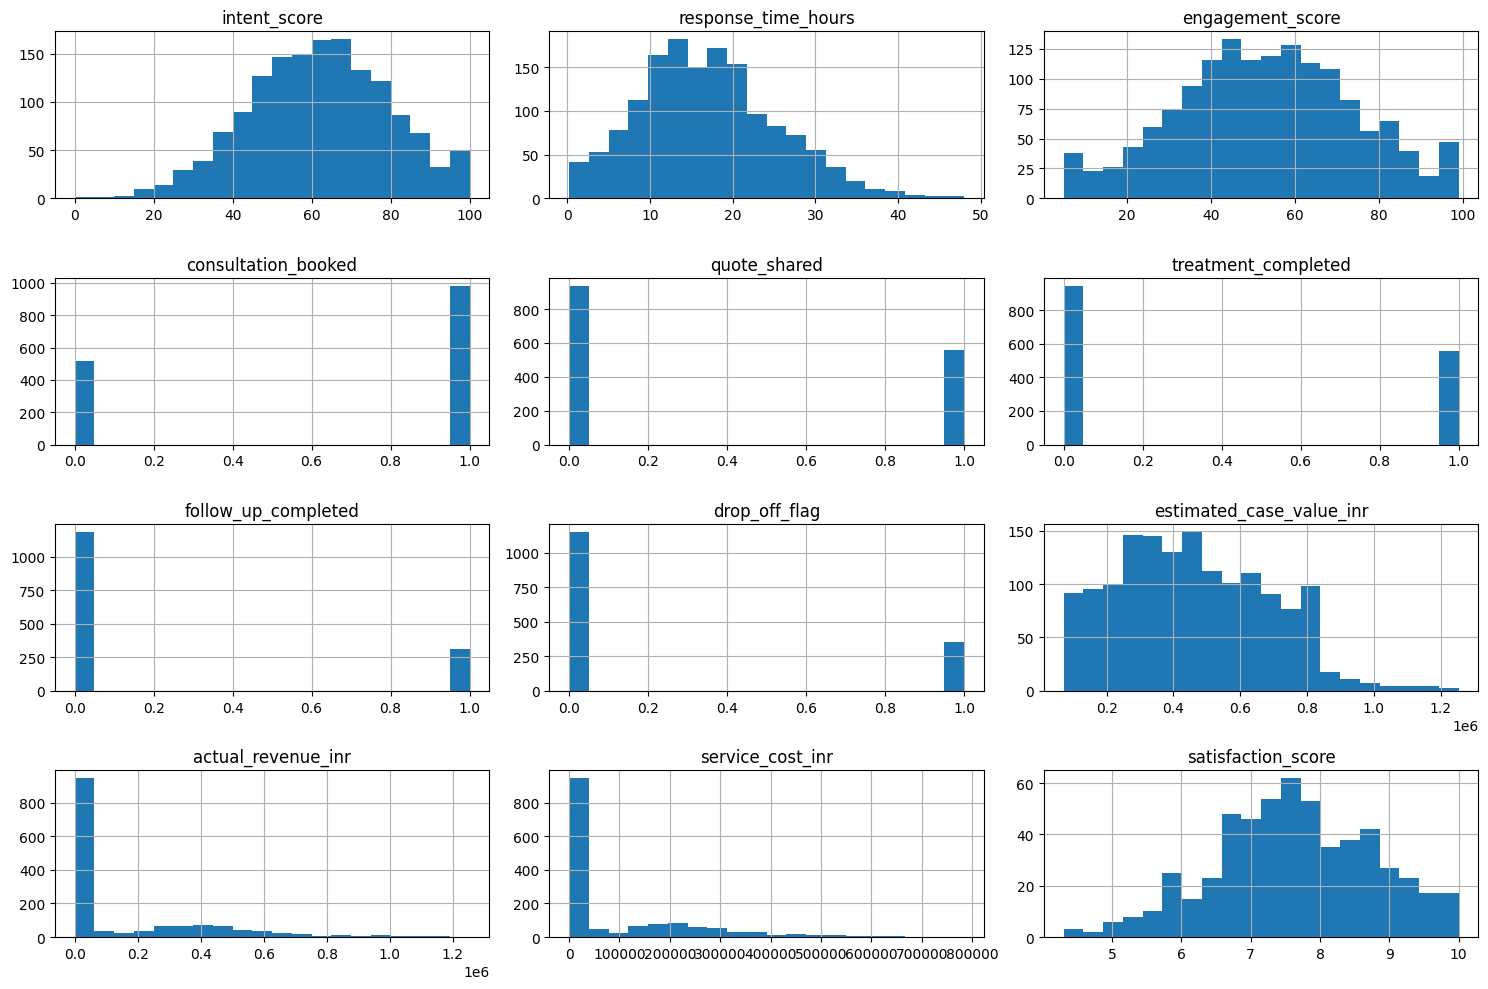

In [ ]:
#Patient Dataset
patient_numeric.hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

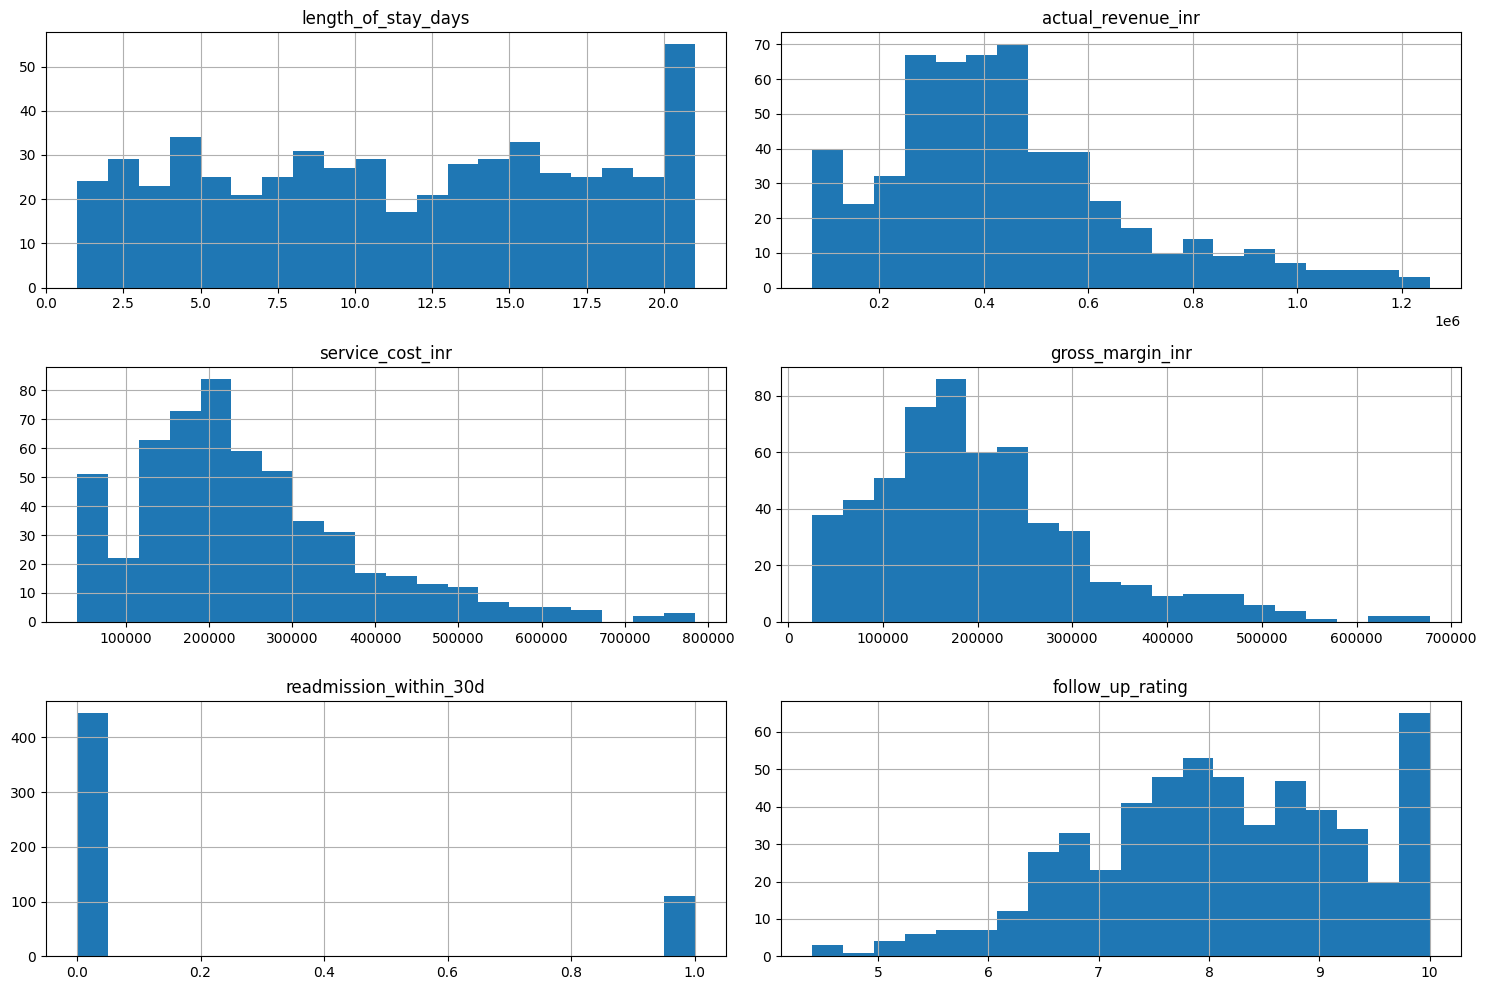

In [ ]:
#Treatment Dataset
treatment_numeric.hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

# **Observations**
### Outlier Analysis Findings

- Revenue and treatment value columns contain expected business outliers.
- Response time shows several extreme observations.
- Engagement score appears normally distributed. (Update based on output)
- No unusual negative values were detected. (Update if needed)

### Recommendation

- Outliers should be reviewed before modeling.
- Consider capping or transformation for highly skewed variables.
- Business-relevant outliers should be retained for analysis.

# **Section 9: Referential Integrity Check**

9.1 Provider ID Validation


In [ ]:
# Check whether all provider IDs in the patient table exist in the provider master table.
print("="*60)
print("PROVIDER ID VALIDATION")
print("="*60)
invalid_providers = patient_df[
    ~patient_df['provider_id'].isin(
        provider_df['provider_id']
    )
]
print("Invalid Provider IDs:",
      len(invalid_providers))
display(invalid_providers.head())

PROVIDER ID VALIDATION
Invalid Provider IDs: 0


,patient_id,inquiry_date,country,age_group,gender,treatment_category,provider_id,lead_source,coordinator_id,budget_band,medical_urgency,intent_score,response_time_hours,engagement_score,consultation_booked,quote_shared,treatment_completed,follow_up_completed,current_stage,drop_off_flag,drop_off_stage,reason_for_drop_off,estimated_case_value_inr,actual_revenue_inr,service_cost_inr,satisfaction_score


9.2 Country Validation

In [ ]:
# Check whether all countries in the patient table exist in the country reference table.
print("="*60)
print("COUNTRY VALIDATION")
print("="*60)
invalid_countries = patient_df[
    ~patient_df['country'].isin(
        country_df['country']
    )
]
print("Invalid Countries:",
      len(invalid_countries))
display(invalid_countries.head())

COUNTRY VALIDATION
Invalid Countries: 0


,patient_id,inquiry_date,country,age_group,gender,treatment_category,provider_id,lead_source,coordinator_id,budget_band,medical_urgency,intent_score,response_time_hours,engagement_score,consultation_booked,quote_shared,treatment_completed,follow_up_completed,current_stage,drop_off_flag,drop_off_stage,reason_for_drop_off,estimated_case_value_inr,actual_revenue_inr,service_cost_inr,satisfaction_score


9.3 Communication → Patient Mapping

In [ ]:
# Check whether the patient_id values in the communication logs table exist in the patient table.
print("="*60)
print("COMMUNICATION TO PATIENT VALIDATION")
print("="*60)
invalid_patients_comm = comm_df[
    ~comm_df['patient_id'].isin(
        patient_df['patient_id']
    )
]
print("Invalid Patient IDs:",
      len(invalid_patients_comm))
display(invalid_patients_comm.head())

COMMUNICATION TO PATIENT VALIDATION
Invalid Patient IDs: 0


,communication_id,patient_id,provider_id,timestamp,channel,interaction_type,sent_by,response_sent,response_delay_hours,follow_up_status


9.4 Treatment → Patient Mapping

In [ ]:
print("="*60)
print("TREATMENT TO PATIENT VALIDATION")
print("="*60)
invalid_patients_treatment = treatment_df[
    ~treatment_df['patient_id'].isin(
        patient_df['patient_id']
    )
]
print("Invalid Patient IDs:",
      len(invalid_patients_treatment))
display(invalid_patients_treatment.head())

TREATMENT TO PATIENT VALIDATION
Invalid Patient IDs: 0


,patient_id,provider_id,treatment_category,treatment_date,length_of_stay_days,actual_revenue_inr,service_cost_inr,gross_margin_inr,readmission_within_30d,follow_up_rating


9.5 Treatment → Provider Mapping

In [ ]:
print("="*60)
print("TREATMENT TO PROVIDER VALIDATION")
print("="*60)
invalid_provider_treatment = treatment_df[
    ~treatment_df['provider_id'].isin(
        provider_df['provider_id']
    )
]
print("Invalid Provider IDs:",
      len(invalid_provider_treatment))
display(invalid_provider_treatment.head())

TREATMENT TO PROVIDER VALIDATION
Invalid Provider IDs: 0


,patient_id,provider_id,treatment_category,treatment_date,length_of_stay_days,actual_revenue_inr,service_cost_inr,gross_margin_inr,readmission_within_30d,follow_up_rating


9.6 Communication → Provider Mapping

In [ ]:
print("="*60)
print("COMMUNICATION TO PROVIDER VALIDATION")
print("="*60)
invalid_provider_comm = comm_df[
    ~comm_df['provider_id'].isin(
        provider_df['provider_id']
    )
]
print("Invalid Provider IDs:",
      len(invalid_provider_comm))
display(invalid_provider_comm.head())

COMMUNICATION TO PROVIDER VALIDATION
Invalid Provider IDs: 0


,communication_id,patient_id,provider_id,timestamp,channel,interaction_type,sent_by,response_sent,response_delay_hours,follow_up_status


9.7 Relationship Summary Table

In [ ]:
relationship_summary = pd.DataFrame({
    'Validation Check': [
        'Patient -> Provider',
        'Patient -> Country',
        'Communication -> Patient',
        'Communication -> Provider',
        'Treatment -> Patient',
        'Treatment -> Provider'
    ],
    'Invalid Records': [
        len(invalid_providers),
        len(invalid_countries),
        len(invalid_patients_comm),
        len(invalid_provider_comm),
        len(invalid_patients_treatment),
        len(invalid_provider_treatment)
    ]
})
display(relationship_summary)

,Validation Check,Invalid Records
0,Patient -> Provider,0
1,Patient -> Country,0
2,Communication -> Patient,0
3,Communication -> Provider,0
4,Treatment -> Patient,0
5,Treatment -> Provider,0


9.8 Database Table Validation

In [ ]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""
db_tables = pd.read_sql(query, conn)
display(db_tables)

NameError: name 'conn' is not defined

# **Observations**
### Referential Integrity Findings

- All patient records successfully map to valid providers.
- All countries are present in the reference table.
- Communication records map correctly to patient records.
- Treatment records map correctly to patient and provider tables.
- No major referential integrity issues were identified.

### Recommendation

- Relationships are suitable for SQL joins and integrated analysis.
- Dataset is ready for funnel analysis, provider scorecards and machine learning workflows.

# **Section 10: Revenue Validation**

10.1 Revenue Summary

In [ ]:
print("="*60)
print("REVENUE SUMMARY")
print("="*60)

display(
    treatment_df['actual_revenue_inr'].describe()
)

REVENUE SUMMARY


,actual_revenue_inr
count,5.540000e+02
mean,4.482405e+05
std,2.385427e+05
min,7.094600e+04
25%,2.853308e+05
50%,4.125840e+05
75%,5.605895e+05
max,1.253660e+06


10.2 Cost Summary

In [ ]:
print("="*60)
print("SERVICE COST SUMMARY")
print("="*60)

display(
    treatment_df['service_cost_inr'].describe()
)

SERVICE COST SUMMARY


,service_cost_inr
count,554.000000
mean,246951.063177
std,137319.509010
min,41365.000000
25%,155425.250000
50%,216245.500000
75%,310636.500000
max,784012.000000


10.3 Margin Summary

In [ ]:
print("="*60)
print("MARGIN SUMMARY")
print("="*60)

display(
    treatment_df['gross_margin_inr'].describe()
)

MARGIN SUMMARY


,gross_margin_inr
count,554.000000
mean,201289.451264
std,113781.479208
min,25198.000000
25%,124366.000000
50%,180685.000000
75%,252002.750000
max,677010.000000


10.4 Negative Revenue Check

In [ ]:
negative_revenue = treatment_df[
    treatment_df['actual_revenue_inr'] < 0
]

print("Negative Revenue Records:",
      len(negative_revenue))

Negative Revenue Records: 0


10.5 Negative Cost Check

In [ ]:
negative_cost = treatment_df[
    treatment_df['service_cost_inr'] < 0
]

print("Negative Cost Records:",
      len(negative_cost))

Negative Cost Records: 0


10.6 Revenue Less Than Cost

In [ ]:
loss_cases = treatment_df[
    treatment_df['actual_revenue_inr'] <
    treatment_df['service_cost_inr']
]
print("Revenue < Cost Cases:",
      len(loss_cases))
display(loss_cases.head())

Revenue < Cost Cases: 0


,patient_id,provider_id,treatment_category,treatment_date,length_of_stay_days,actual_revenue_inr,service_cost_inr,gross_margin_inr,readmission_within_30d,follow_up_rating


10.7 Recalculate Margin

In [ ]:
#PRD formula: Gross Margin = Revenue − Cost
treatment_df['calculated_margin'] = (
    treatment_df['actual_revenue_inr']
    -
    treatment_df['service_cost_inr']
)

10.8 Margin Validation

In [ ]:
margin_difference = (
    treatment_df['gross_margin_inr']
    -
    treatment_df['calculated_margin']
)
print(
    "Margin Mismatch Records:",
    (margin_difference != 0).sum()
)

Margin Mismatch Records: 0


10.9 Revenue Distribution

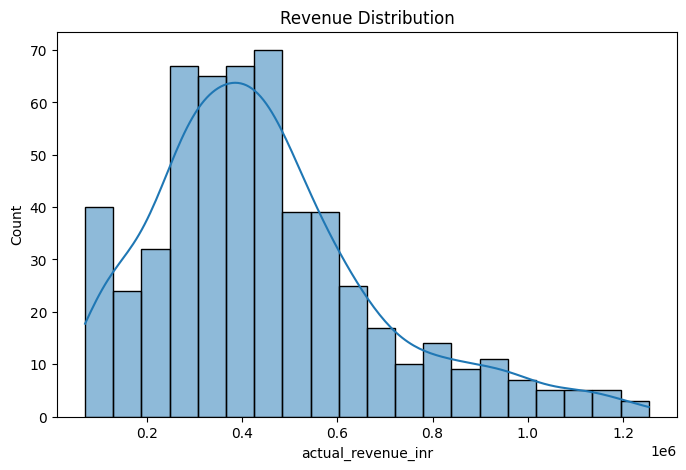

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    treatment_df['actual_revenue_inr'],
    bins=20,
    kde=True
)
plt.title("Revenue Distribution")
plt.show()

10.10 Cost Distribution

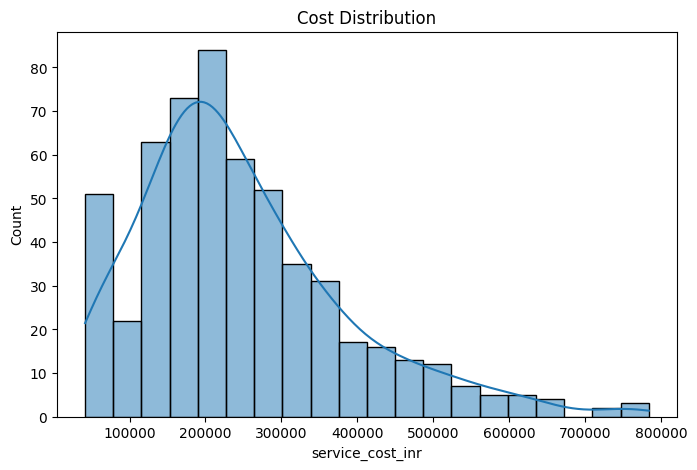

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    treatment_df['service_cost_inr'],
    bins=20,
    kde=True
)
plt.title("Cost Distribution")
plt.show()

10.11 Margin Distribution

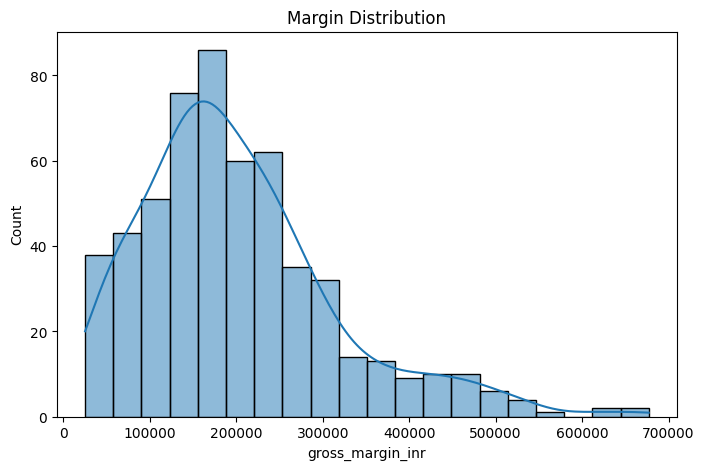

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    treatment_df['gross_margin_inr'],
    bins=20,
    kde=True
)
plt.title("Margin Distribution")
plt.show()

10.12 High Revenue Cases

In [ ]:
# Top 10 revenue cases.
top_revenue = treatment_df.sort_values(
    by='actual_revenue_inr',
    ascending=False
)
display(
    top_revenue.head(10)
)

,patient_id,provider_id,treatment_category,treatment_date,length_of_stay_days,actual_revenue_inr,service_cost_inr,gross_margin_inr,readmission_within_30d,follow_up_rating,calculated_margin
75,MTE-PAT-00203,PVD-006,Transplant Evaluation,2025-04-24,2,1253660,637822,615838,0,10.0,615838
46,MTE-PAT-00137,PVD-025,Transplant Evaluation,2025-06-27,15,1233113,556103,677010,0,9.7,677010
165,MTE-PAT-00432,PVD-020,Transplant Evaluation,2025-07-17,21,1231758,735003,496755,0,9.7,496755
498,MTE-PAT-01370,PVD-020,Transplant Evaluation,2026-01-09,17,1168953,784012,384941,0,6.8,384941
452,MTE-PAT-01236,PVD-010,Transplant Evaluation,2025-04-23,19,1162913,496608,666305,0,7.8,666305
493,MTE-PAT-01354,PVD-002,Transplant Evaluation,2025-07-04,14,1153072,761613,391459,0,7.8,391459
406,MTE-PAT-01120,PVD-029,Transplant Evaluation,2025-03-30,4,1137859,653162,484697,0,7.6,484697
59,MTE-PAT-00170,PVD-027,Transplant Evaluation,2025-03-26,16,1136471,731346,405125,0,8.1,405125
49,MTE-PAT-00143,PVD-027,Transplant Evaluation,2025-04-19,20,1132907,599043,533864,0,8.7,533864
533,MTE-PAT-01446,PVD-015,Transplant Evaluation,2025-05-08,15,1123821,760378,363443,0,8.6,363443


10.13 Business Rule Validation Summary

In [ ]:
business_validation = pd.DataFrame({
    'Validation': [
        'Negative Revenue',
        'Negative Cost',
        'Revenue Less Than Cost',
        'Margin Mismatch'
    ],
    'Issue Count': [
        len(negative_revenue),
        len(negative_cost),
        len(loss_cases),
        (margin_difference != 0).sum()
    ]
})
display(business_validation)

,Validation,Issue Count
0,Negative Revenue,0
1,Negative Cost,0
2,Revenue Less Than Cost,0
3,Margin Mismatch,0


# **Observations**
### Revenue & Cost Validation Findings

- Revenue values were reviewed for consistency.
- Cost values were validated.
- Margin calculations were verified against the business rule:
  Gross Margin = Revenue − Cost.
- High-value treatment cases were identified.
- Financial metrics appear suitable for profitability analysis.

### Recommendation

- Investigate any negative revenue or cost records.
- Review cases where revenue is lower than service cost.
- Use validated financial metrics for provider scorecards and margin analysis.